In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Linear Order Book
Define margin sizes, fixed price step difference  
Find number of steps, size of offers  

Should include 'padding' - define area to be shown and include those prices with size = 0

Include parameter: alpha & beta - How far from mid are first bid and ask prices

Change bid price to percentage

### Parameters

In [2]:
mid_price = 0
beta, alpha = -0.5/100, 0.5/100 # spread from mid to first bid (beta) and mid to first ask (alpha)
min_bid, max_ask = -10/100, 8/100
min_price, max_price = -12/100, 12/100 # determines range of x-axis
bid_depth, ask_depth = 120000, 80000 # Cumulative size of bids and asks

tick_size = 0.01/100 # theta ; cannot be larger than beta or alpha

# v_p = bid/ask volume at specific price
# Cumulative bid volume = V_b
# Cumulative ask volume = V_a

In [3]:
# Get total number of ticks indcluding where size=0, such as below min_bid, above max_ask and within spread area
# add 1 to account for midpoint (e.g. 600 ticks for bid side, 600 for ask side, plus midpoint)
total_ticks = int((max_price-min_price)/tick_size)+1
total_ticks

2401

### Find Sizes of bids and asks

In [4]:
# Find number of ticks for each section
empty_bid_ticks = round((min_bid-min_price)/tick_size) # ticks to left of min_bid
bid_ticks = round((beta-min_bid)/tick_size)
spread_ticks = round((alpha-beta)/tick_size)+1
ask_ticks = round((max_ask-alpha)/tick_size)
empty_ask_ticks = round((max_price-max_ask)/tick_size) # ticks to right of max_ask

print(f"{empty_bid_ticks} \n{bid_ticks} \n{spread_ticks} \n{ask_ticks} \n{empty_ask_ticks}")

# Checking all sections' ticks sum up to correct total
print('Sum of ticks:', bid_ticks + empty_bid_ticks + spread_ticks + ask_ticks + empty_ask_ticks)

200 
950 
101 
750 
400
Sum of ticks: 2401


In [5]:
bid_size = bid_depth/bid_ticks
ask_size = ask_depth/ask_ticks

In [6]:
# Creating array with size of bids and asks for all prices
array_0 = np.zeros(empty_bid_ticks)
array_1 = np.full(bid_ticks, bid_size)
array_2 = np.zeros(spread_ticks)
array_3 = np.full(ask_ticks, ask_size)
array_4 = np.zeros(empty_ask_ticks)

sizes = np.concatenate((array_0, array_1, array_2, array_3, array_4))

In [7]:
# price array needs to span all of min price to max price and have length == to total_ticks
prices = np.linspace(min_price, max_price, total_ticks)

In [8]:
# Creating df with all prices and their respective order size
df = pd.DataFrame({'prices': prices, 'sizes': sizes})
df

,prices,sizes
0,-0.1200,0.0
1,-0.1199,0.0
2,-0.1198,0.0
3,-0.1197,0.0
4,-0.1196,0.0
...,...,...
2396,0.1196,0.0
2397,0.1197,0.0
2398,0.1198,0.0
2399,0.1199,0.0


# Plot

In [9]:
# Getting cumulative bid data for plot
bid_end_tick = empty_bid_ticks+bid_ticks+int((spread_ticks-1)/2)
bid = df.iloc[:bid_end_tick].copy()
bid.sort_values(by=["prices"], ascending=False, inplace = True)
bid['cumulative_bid'] = bid['sizes'].cumsum()
bid.reset_index(inplace=True, drop=True)
bid

,prices,sizes,cumulative_bid
0,-0.0001,0.0,0.0
1,-0.0002,0.0,0.0
2,-0.0003,0.0,0.0
3,-0.0004,0.0,0.0
4,-0.0005,0.0,0.0
...,...,...,...
1195,-0.1196,0.0,120000.0
1196,-0.1197,0.0,120000.0
1197,-0.1198,0.0,120000.0
1198,-0.1199,0.0,120000.0


In [10]:
# Getting cumulative ask data for plot
ask_start_tick = empty_bid_ticks+bid_ticks+int((spread_ticks-1)/2)+1
ask = df.iloc[ask_start_tick:].copy().reset_index(drop=True)
ask['cumulative_ask'] = ask['sizes'].cumsum()
ask

,prices,sizes,cumulative_ask
0,0.0001,0.0,0.0
1,0.0002,0.0,0.0
2,0.0003,0.0,0.0
3,0.0004,0.0,0.0
4,0.0005,0.0,0.0
...,...,...,...
1195,0.1196,0.0,80000.0
1196,0.1197,0.0,80000.0
1197,0.1198,0.0,80000.0
1198,0.1199,0.0,80000.0


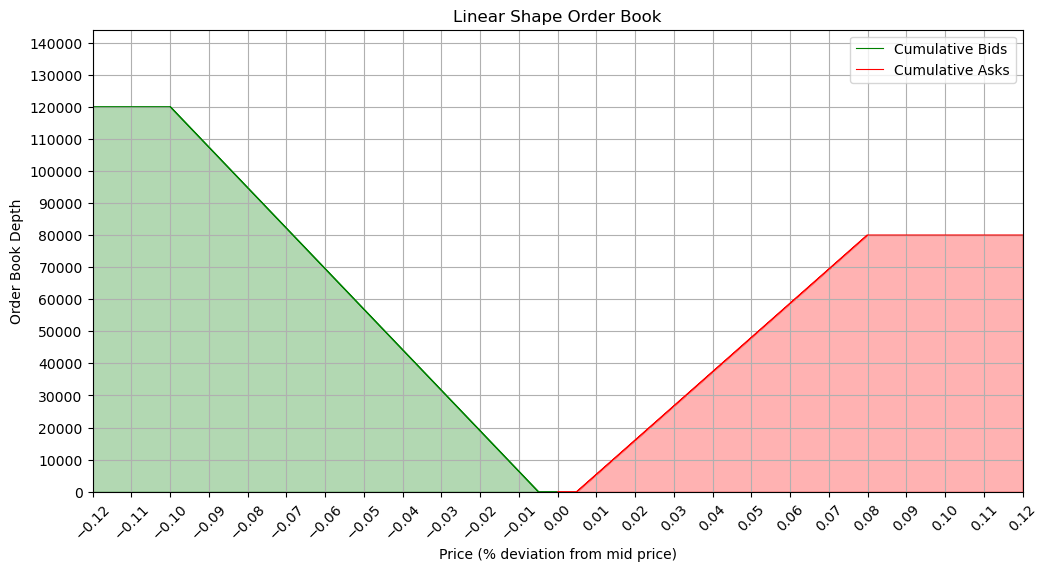

In [11]:
# setting 'x1' and 'y1' for the first plot
x1 = bid['prices']
y1 = bid['cumulative_bid']

# Assuming you have two arrays 'x2' and 'y2' for the second plot
x2 = ask['prices']
y2 = ask['cumulative_ask']

# Create plot
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

# Plot the bids in green
plt.plot(x1, y1, color='green', label='Cumulative Bids', drawstyle="steps", linewidth=0.8)
# Plot the asks in red
plt.plot(x2, y2, color='red', label='Cumulative Asks', drawstyle="steps", linewidth=0.8)

# Fill area under bids and asks with colour
plt.fill_between(x1, y1, step="pre", alpha=0.3, color='green')
plt.fill_between(x2, y2, step="pre", alpha=0.3, color='red')

# Add labels and title
plt.xlabel('Price (% deviation from mid price)')
plt.ylabel('Order Book Depth')
plt.title('Linear Shape Order Book')

# Axis options
plt.xticks(np.arange(min_price, max_price+tick_size, 0.01), rotation=45)
plt.yticks(np.arange(0, max(bid_depth, ask_depth)*1.2, 10000))
# Set the x-axis and y-axis limits
plt.xlim(min(x1), max(x2))
plt.ylim(0, max(max(y1), max(y2))*1.2)

# Add a legend to differentiate the plots and grid
plt.legend()
plt.grid(True, 'both')

# Show the plot
plt.show()

# Test for df structure

In [12]:
mid_price = 0
beta, alpha = -0.5/100, 0.5/100 # spread from mid to first bid (beta) and mid to first ask (alpha)
min_bid, max_ask = -10/100, 8/100
max_deviation =  12/100 # determines range of x-axis
bid_depth, ask_depth = 120000, 80000 # Cumulative size of bids and asks

tick_size = 0.01/100 # theta ; cannot be larger than beta or alpha

In [13]:
total_ticks = int(max_deviation/tick_size)
total_ticks

1200

In [14]:
# price array needs to span all of min price to max price and have length = to total_ticks
prices_list = np.linspace(0, max_deviation, total_ticks)

# Initialising sizes
empty_sizes = np.zeros(total_ticks)

In [15]:
df = pd.DataFrame({'price': prices_list, 'bid_size': empty_sizes, 'ask_size': empty_sizes})
df

,price,bid_size,ask_size
0,0.0000,0.0,0.0
1,0.0001,0.0,0.0
2,0.0002,0.0,0.0
3,0.0003,0.0,0.0
4,0.0004,0.0,0.0
...,...,...,...
1195,0.1196,0.0,0.0
1196,0.1197,0.0,0.0
1197,0.1198,0.0,0.0
1198,0.1199,0.0,0.0


In [16]:
bid_ticks = round((beta-min_bid)/tick_size)
ask_ticks = round((max_ask-alpha)/tick_size)
print(bid_ticks, ask_ticks)

950 750


In [17]:
bid_size = bid_depth/bid_ticks
ask_size = ask_depth/ask_ticks
print(bid_size, ask_size)

126.3157894736842 106.66666666666667


In [18]:
beta_ticks = -round(beta/tick_size) # add 1 to account for mid-point
alpha_ticks = round(alpha/tick_size)
print(beta_ticks, alpha_ticks)

50 50


In [19]:
pd.set_option('display.max_rows', 15) #defualt = 15
df['bid_size'].loc[beta_ticks+1:bid_ticks+beta_ticks] = bid_size
df['ask_size'].loc[alpha_ticks+1:ask_ticks+alpha_ticks] = ask_size
df['cumulative_bid'] = df['bid_size'].cumsum()
df['cumulative_ask'] = df['ask_size'].cumsum()
df

,price,bid_size,ask_size,cumulative_bid,cumulative_ask
0,0.0000,0.0,0.0,0.0,0.0
1,0.0001,0.0,0.0,0.0,0.0
2,0.0002,0.0,0.0,0.0,0.0
3,0.0003,0.0,0.0,0.0,0.0
4,0.0004,0.0,0.0,0.0,0.0
...,...,...,...,...,...
1195,0.1196,0.0,0.0,120000.0,80000.0
1196,0.1197,0.0,0.0,120000.0,80000.0
1197,0.1198,0.0,0.0,120000.0,80000.0
1198,0.1199,0.0,0.0,120000.0,80000.0


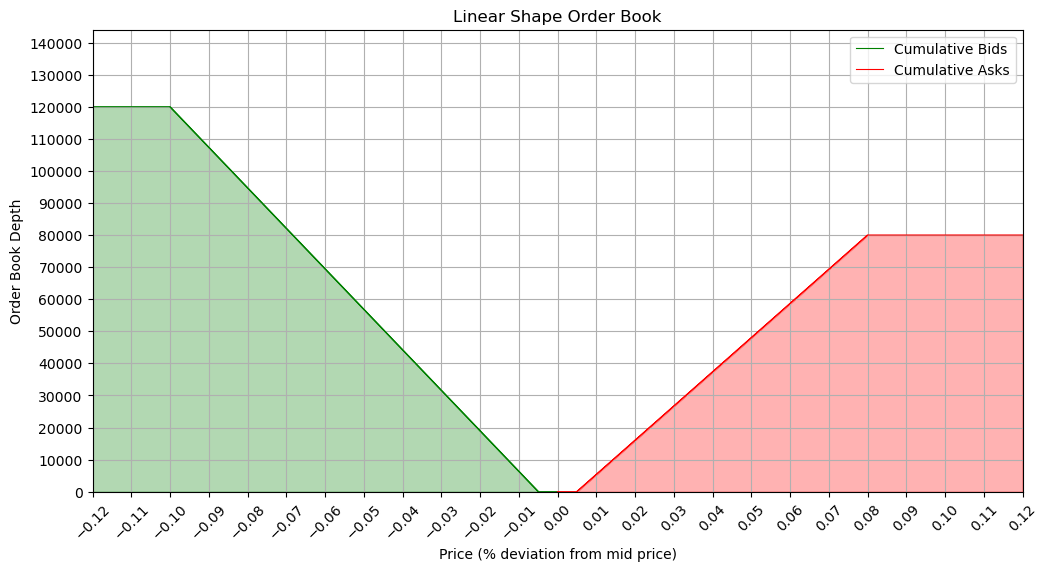

In [20]:
# Plot test

# setting 'x1' and 'y1' for the first plot
x1 = df['price'].multiply(-1)
y1 = df['cumulative_bid']

# Assuming you have two arrays 'x2' and 'y2' for the second plot
x2 = df['price']
y2 = df['cumulative_ask']

# Create plot
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

# Plot the bids in green
plt.plot(x1, y1, color='green', label='Cumulative Bids', drawstyle="steps", linewidth=0.8)
# Plot the asks in red
plt.plot(x2, y2, color='red', label='Cumulative Asks', drawstyle="steps", linewidth=0.8)

# Fill area under bids and asks with colour
plt.fill_between(x1, y1, step="pre", alpha=0.3, color='green')
plt.fill_between(x2, y2, step="pre", alpha=0.3, color='red')

# Add labels and title
plt.xlabel('Price (% deviation from mid price)')
plt.ylabel('Order Book Depth')
plt.title('Linear Shape Order Book')

# Axis options
plt.xticks(np.arange(-max_deviation, max_deviation+tick_size, 0.01), rotation=45)
plt.yticks(np.arange(0, max(bid_depth, ask_depth)*1.2, 10000))
# Set the x-axis and y-axis limits
plt.xlim(min(x1), max(x2))
plt.ylim(0, max(max(y1), max(y2))*1.2)

# Add a legend to differentiate the plots and grid
plt.legend()
plt.grid(True, 'both')

# Show the plot
plt.show()